Generating updated high-resolution SVG metric visualizations...


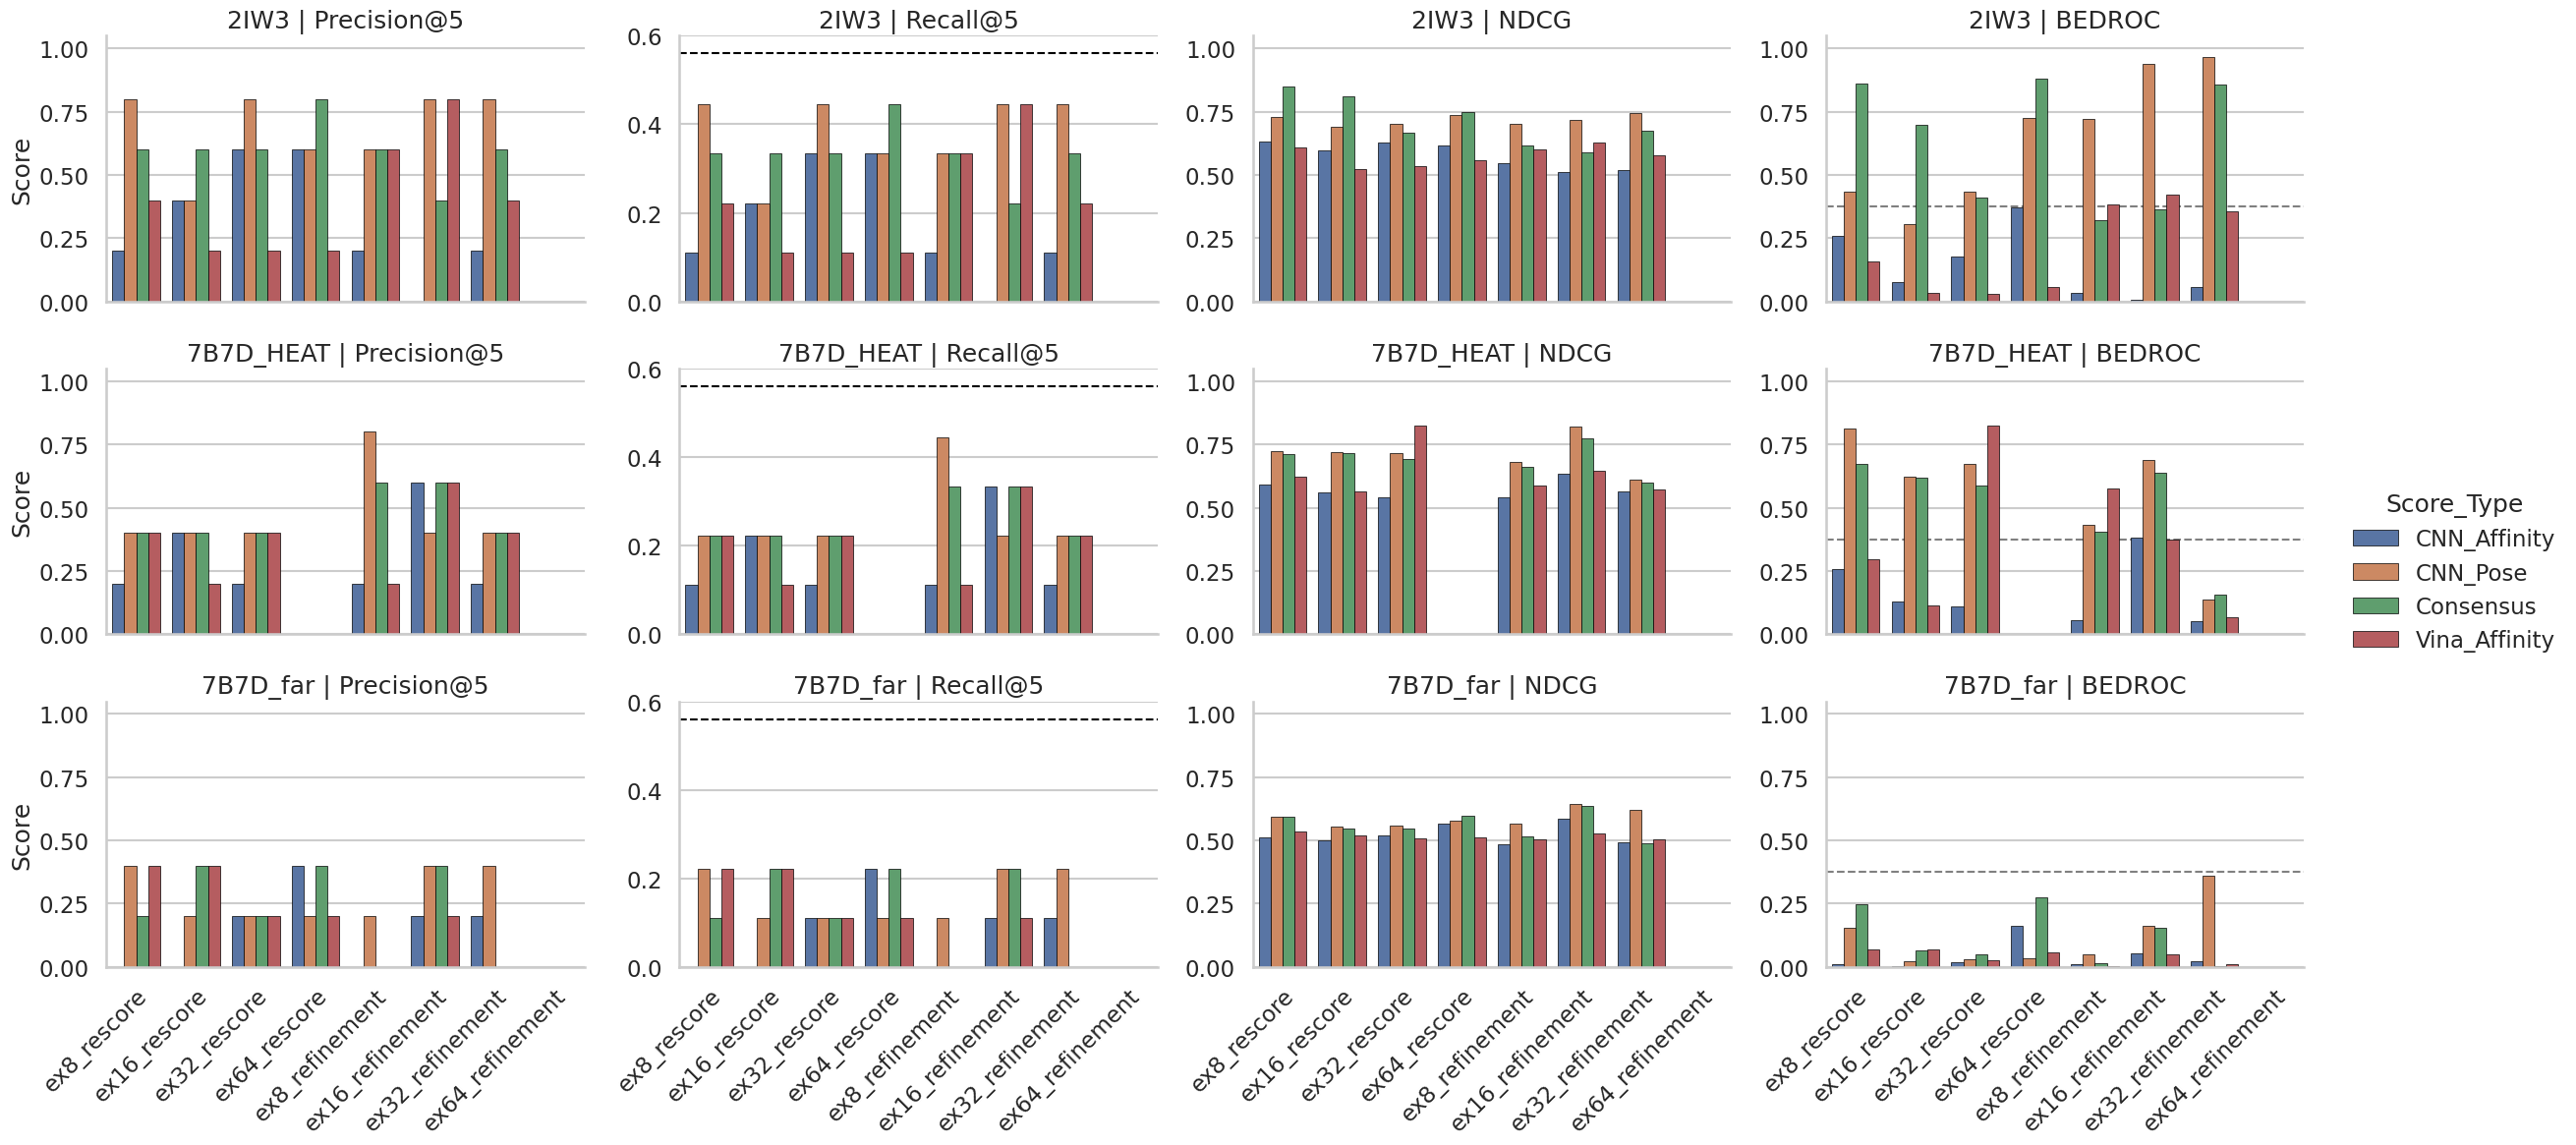

Success! Scalable Vector Graphic saved as faceted_metrics_grid_publication_v2.svg


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating updated high-resolution SVG metric visualizations...")

# 1. Load the data
df = pd.read_csv('master_hyperparameter.csv')

# 2. Integrate the "INTERESTING" run
# Drop the original 7B7D_HEAT_ex8_refinement rows entirely
df = df[~((df['Pocket'] == '7B7D_HEAT') & (df['Run_Name'] == '7B7D_HEAT_ex8_refinement'))]

# Rename the INTERESTING run so it mathematically replaces the old run in the graphs
df['Run_Name'] = df['Run_Name'].str.replace('7B7D_HEAT_ex8_refinement_INTERESTING', '7B7D_HEAT_ex8_refinement')

# 3. Clean up the data for presentation
df_clean = df[df['Pocket'] != 'Other'].copy()

def shorten_run_name(row):
    return row['Run_Name'].replace(row['Pocket'] + '_', '')

df_clean['Short_Name'] = df_clean.apply(shorten_run_name, axis=1)

# 4. Resort the X-axis
# Define the exact requested order. pd.Categorical forces Seaborn to respect this order.
desired_order = [
    'ex8_rescore', 'ex16_rescore', 'ex32_rescore', 'ex64_rescore',
    'ex8_refinement', 'ex16_refinement', 'ex32_refinement', 'ex64_refinement'
]
df_clean['Short_Name'] = pd.Categorical(df_clean['Short_Name'], categories=desired_order, ordered=True)

# 5. Melt the DataFrame for Seaborn compatibility
metrics_list = ['Precision@5', 'Recall@5', 'NDCG', 'BEDROC']
df_melted = df_clean.melt(id_vars=['Pocket', 'Short_Name', 'Score_Type'], 
                          value_vars=metrics_list, 
                          var_name='Metric', 
                          value_name='Score')

# ==========================================
# CUSTOMIZATION ZONE
# ==========================================

sns.set_theme(style="whitegrid", context="talk") 

# A brighter, highly distinct color palette for maximum visibility
custom_palette = {
    "CNN_Affinity": "#4C72B0",  # Deep Blue
    "CNN_Pose":     "#DD8452",  # Vibrant Orange
    "Consensus":    "#55A868",  # Forest Green
    "Vina_Affinity":"#C44E52"   # Crimson Red
}

# ==========================================

# 6. Build the FacetGrid
g = sns.catplot(
    data=df_melted,
    x='Short_Name',      
    y='Score',           
    hue='Score_Type',    
    row='Pocket',        
    col='Metric',        
    kind='bar',          
    height=4,            
    aspect=1.5,          
    palette=custom_palette, 
    edgecolor='black',   
    linewidth=0.5,
    sharey="col"
)

# 7. Polish the axes, limits, and labels
for ax in g.axes.flat:
    # Anchor the rotated text so it aligns perfectly with the ticks
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.set_xlabel('')
    
    graph_title = ax.get_title()
    
    if 'Recall@5' in graph_title:
        # Extend the y-limit slightly to 0.60 so the 0.56 line isn't cut off by the top border
        ax.set_ylim(0, 0.60)
        ax.axhline(y=0.56, color='black', linestyle='--', linewidth=1.5, zorder=0)
    else:
        ax.set_ylim(0, 1.05)
        
    if 'BEDROC' in graph_title:
        # Random baseline for BEDROC (9 hits in 24 total molecules)
        ax.axhline(y=0.375, color='gray', linestyle='--', linewidth=1.5, zorder=0)

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.tight_layout()

# 8. Save as Scalable Vector Graphic (SVG)
output_image = 'faceted_metrics_grid_publication_v2.svg'
plt.savefig(output_image, format='svg', bbox_inches='tight')
plt.show()
plt.close()

print(f"Success! Scalable Vector Graphic saved as {output_image}")